# ============================================
# 📊 CASY Equity Research Notebook
# Intrinsic Value (DCF), WACC, and Peer Analysis
# ============================================


### **Introduction**

Casey's General Stores (NASDAQ: CASY) is a leading U.S. convenience store chain
with a differentiated business model combining fuel retail, grocery, and
high-margin prepared food.

The company operates in rural and suburban markets, benefiting from limited
competition and strong customer loyalty.

From an investment perspective, Casey’s is interesting because it combines:
- Defensive demand (fuel and food)
- Growth drivers (store expansion and prepared food margins)

This notebook evaluates whether the stock is overvalued or undervalued using:
- Financial analysis
- Normalized Free Cash Flow (FCF)
- WACC estimation
- Discounted Cash Flow (DCF)
- Peer comparison


### **Data Limitation Note:**

Yahoo Finance provides only ~4–5 years of financial statement data.

To address this limitation:
- Free Cash Flow is normalized to reduce volatility
- Conservative growth assumptions are used
- A 5-year DCF model is applied
- Sensitivity analysis is included

This approach reflects real-world valuation practices when long-term data is limited.


### **Install & Imports**

In [ ]:
!pip install yfinance pandas numpy matplotlib

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **Define Tickers**

In [ ]:
tickers = {
    "CASY": "Caseys",
    "MUSA": "Murphy USA",
    "ATD.TO": "Couche-Tard",
    "SVNDY": "Seven & i"
}

data = {t: yf.Ticker(t) for t in tickers}

### **Get Financial Data**

In [ ]:
stock = data["CASY"]

income = stock.financials.T
cashflow = stock.cashflow.T

financials = pd.DataFrame()

if "Total Revenue" in income.columns:
    financials["Revenue"] = income["Total Revenue"]

if "Free Cash Flow" in cashflow.columns:
    financials["FCF"] = cashflow["Free Cash Flow"]
else:
    financials["FCF"] = cashflow["Total Cash From Operating Activities"] - cashflow["Capital Expenditures"]

financials = financials.dropna().sort_index()

print("=== Financials ===")
display(financials)

=== Financials ===


,Revenue,FCF
2022-04-30,1.295259e+10,462266000.0
2023-04-30,1.509448e+10,405383000.0
2024-04-30,1.486291e+10,370949000.0
2025-04-30,1.594090e+10,584630000.0


### **Financial Analysis**

The financial data for Casey’s General Stores shows a generally positive revenue trend,
increasing from approximately \$13.0B in 2022 to nearly $16.0B in 2025. This suggests
continued business expansion, likely driven by new store openings and strong performance
in core segments such as fuel and prepared food.

However, Free Cash Flow (FCF) exhibits noticeable volatility over the same period.
FCF declined between 2022 and 2024 before rebounding significantly in 2025.

This behavior indicates that cash generation is influenced by factors such as:
- Capital expenditures (store expansion, reinvestment)
- Fuel margin fluctuations
- Working capital changes

From a valuation perspective, this volatility is critical:

Raw FCF cannot be directly used as a stable indicator of intrinsic value.

Therefore, in the next step, we will normalize FCF to better estimate the company's
sustainable cash-generating ability.

### **Revenue + FCF**

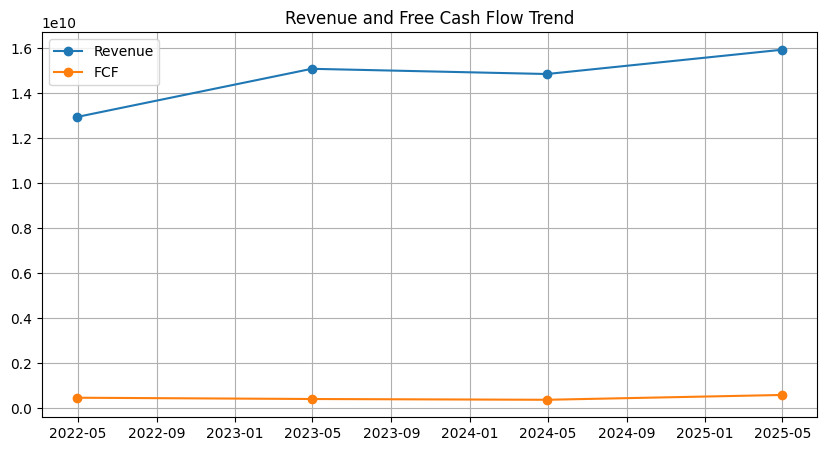

In [ ]:
# 📊 GRAPH 1
plt.figure(figsize=(10,5))

plt.plot(financials.index, financials["Revenue"], marker='o', label="Revenue")
plt.plot(financials.index, financials["FCF"], marker='o', label="FCF")

plt.title("Revenue and Free Cash Flow Trend")
plt.legend()
plt.grid()

plt.show()

### Trend Analysis

The chart shows a clear upward trend in revenue for Casey’s General Stores,
indicating consistent business expansion over the analyzed period.

Revenue grew steadily from approximately **\$13B in 2022 to nearly \$16B in 2025**,
with only a slight slowdown in 2024.

In contrast, Free Cash Flow (FCF) is more volatile, declining before recovering strongly.

This highlights that cash flow is influenced by capital expenditures,
fuel margins, and operational factors.

From a valuation perspective, this reinforces the need to normalize FCF.

### **Normalize Free Cash Flow**

In [ ]:
# Remove outliers using interquartile range (IQR)
q_low = financials["FCF"].quantile(0.25)
q_high = financials["FCF"].quantile(0.75)

filtered_fcf = financials["FCF"][
    (financials["FCF"] >= q_low) &
    (financials["FCF"] <= q_high)
]

normalized_fcf = filtered_fcf.mean()

print("Normalized FCF:", normalized_fcf)

Normalized FCF: 433824500.0


### Free Cash Flow Normalization

Free Cash Flow (FCF) was normalized using an interquartile range (IQR) approach
to reduce the impact of outliers and short-term volatility.

The resulting normalized FCF is approximately **434 million USD**, which provides
a more stable estimate of the company’s sustainable cash-generating capacity.

This adjustment is important because raw FCF can be distorted by:
- Temporary capital expenditure spikes
- Changes in working capital
- Fuel margin volatility

By focusing on a normalized value, we improve the reliability of the valuation model
and avoid overestimating intrinsic value based on unusually strong periods.

### **FCF vs Normalized**

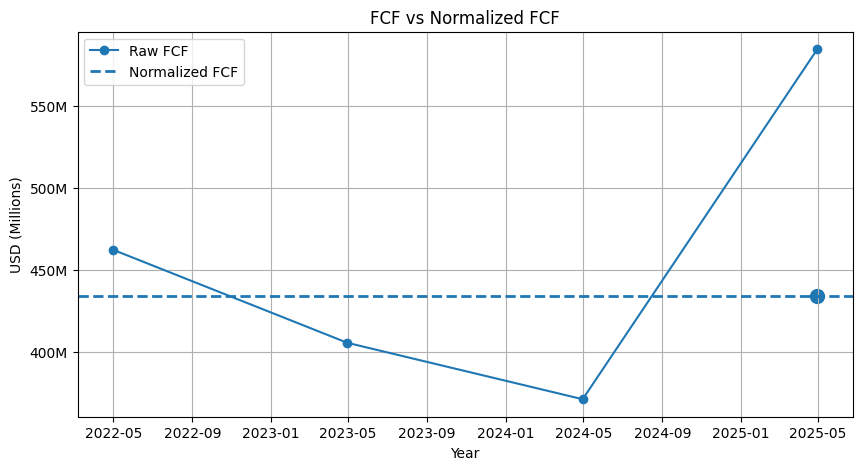

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(financials.index, financials["FCF"], marker='o', label="Raw FCF")
plt.axhline(y=normalized_fcf, linestyle='--', linewidth=2, label="Normalized FCF")

# Highlight normalized value
plt.scatter(financials.index[-1], normalized_fcf, s=100)

plt.title("FCF vs Normalized FCF")
plt.xlabel("Year")
plt.ylabel("USD (Millions)")

plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x/1e6:.0f}M')

plt.legend()
plt.grid()

plt.show()

### **FCF Normalization Analysis**

The chart highlights the relationship between reported Free Cash Flow (FCF) and the normalized FCF level.

FCF shows clear volatility over the analyzed period, declining from 2022 to 2024 before experiencing a strong rebound in 2025. This pattern suggests that short-term factors such as capital expenditures, working capital changes, and fuel margin fluctuations significantly impact cash generation.

The normalized FCF, estimated at approximately 434 million USD, represents a more stable and sustainable level of cash flow. This value is visualized as a horizontal reference line and highlighted point.

Notably, the most recent FCF figure is well above the normalized level, indicating that it may reflect a temporary peak rather than a sustainable trend.

From a valuation perspective, relying on this elevated figure could lead to an overestimation of intrinsic value. Therefore, using normalized FCF provides a more conservative and realistic basis for the DCF model.

### **Assumptions**

In [ ]:
growth_rate = 0.06        # Conservative growth (6%)
terminal_growth = 0.025   # Long-term GDP-like growth

print("Growth Rate:", growth_rate)
print("Terminal Growth:", terminal_growth)

Growth Rate: 0.06
Terminal Growth: 0.025


### **Growth Assumptions**

The model assumes a revenue and cash flow growth rate of 6% over the projection period.
This reflects a moderate and sustainable expansion, consistent with Casey’s business model,
which is driven by store growth, operational improvements, and stable demand in fuel and food segments.

The terminal growth rate is set at 2.5%, representing a long-term growth rate aligned with
expected GDP and inflation. This assumption ensures that the model remains conservative
and avoids overstating the company’s long-term potential.

Importantly, the terminal growth rate is kept below the discount rate (WACC),
which is a necessary condition for a valid DCF model.

### **WACC Calculation**

In [ ]:
info = stock.info

beta = info.get("beta", 0.65)
risk_free_rate = 0.04
market_return = 0.09

cost_of_equity = risk_free_rate + beta * (market_return - risk_free_rate)

# Cost of debt approximation
try:
    interest_expense = stock.financials.loc["Interest Expense"][0]
    total_debt = stock.balance_sheet.loc["Total Debt"][0]
    cost_of_debt = abs(interest_expense) / total_debt
except:
    cost_of_debt = 0.05

tax_rate = info.get("taxRate", 0.23)

equity_weight = 0.7
debt_weight = 0.3

wacc = (
    cost_of_equity * equity_weight +
    cost_of_debt * (1 - tax_rate) * debt_weight
)

print("Cost of Equity:", cost_of_equity)
print("Cost of Debt:", cost_of_debt)
print("WACC:", wacc)

Cost of Equity: 0.07024999999999999
Cost of Debt: 0.05
WACC: 0.06072499999999999


### **WACC Estimation**

The Weighted Average Cost of Capital (WACC) is estimated at approximately 6.1%.

The cost of equity is calculated using the CAPM model, resulting in 7.0%,
driven by a relatively low beta 0.65, which reflects the defensive nature
of the business.

The cost of debt is estimated at approximately 5%, based on interest expense
relative to total debt.

Overall, the WACC is relatively low, indicating that the company is perceived
as a stable and low-risk investment.

However, a lower WACC increases the present value of future cash flows,
which can lead to higher valuation estimates. Therefore, this assumption
should be interpreted cautiously and tested through sensitivity analysis.

In [ ]:
wacc_conservative = 0.08
print("Conservative WACC:", wacc_conservative)

Conservative WACC: 0.08


### **Conservative WACC Scenario**

In addition to the base-case WACC of approximately 6.1%, a more conservative
discount rate of 8% is also considered.

This adjustment reflects potential risks that may not be fully captured in
the base assumptions, such as:
- Macroeconomic uncertainty
- Interest rate fluctuations
- Execution risk in expansion strategy
- Variability in fuel margins and consumer demand

Using a higher WACC provides a more conservative valuation by increasing the
discount applied to future cash flows.

This approach helps assess how sensitive the intrinsic value is to changes
in perceived risk and ensures that the valuation is not overly optimistic.

### **DCF Model (5 Years)**

In [ ]:
projection_years = 5

fcf = normalized_fcf
discounted_fcf = []

for year in range(1, projection_years + 1):
    fcf *= (1 + growth_rate)
    discounted_fcf.append(fcf / ((1 + wacc) ** year))

terminal_value = (fcf * (1 + terminal_growth)) / (wacc - terminal_growth)
terminal_discounted = terminal_value / ((1 + wacc) ** projection_years)

enterprise_value = sum(discounted_fcf) + terminal_discounted

print("Enterprise Value:", enterprise_value)

Enterprise Value: 14569228552.445236


### **Discounted Cash Flow (DCF) Valuation**

The estimated enterprise value is approximately **14.6 billion USD** based on a
5-year DCF model using normalized Free Cash Flow.

The model assumes:
- A normalized FCF of ~434 million USD
- A growth rate of 6% over the projection period
- A terminal growth rate of 2.5%
- A WACC of approximately 6.1%

A significant portion of the total valuation is derived from the terminal value,
which reflects the long-term cash-generating potential of the business.

This highlights an important characteristic of DCF models:

The valuation is highly sensitive to assumptions regarding growth and discount rates,
particularly in the terminal phase.

Therefore, the results should be interpreted alongside sensitivity analysis
and alternative scenarios.

### **Projected Free Cash Flow**

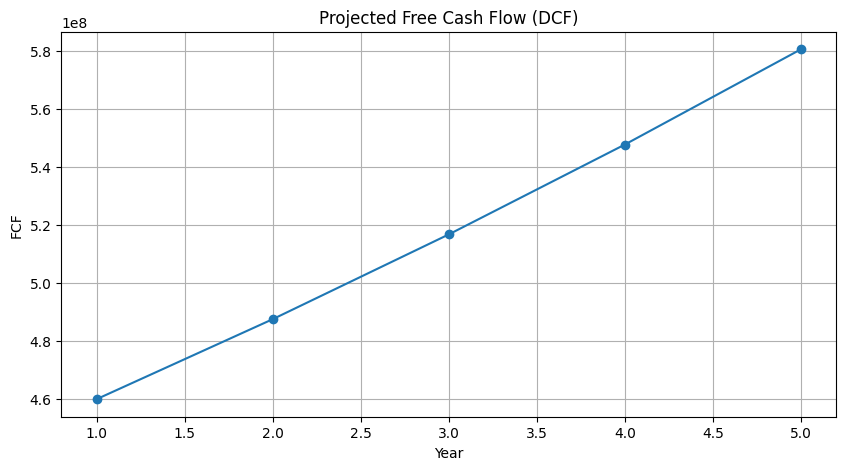

In [ ]:
# 📊 GRAPH 3
fcf_proj_values = []
fcf_temp = normalized_fcf

for year in range(1, projection_years + 1):
    fcf_temp *= (1 + growth_rate)
    fcf_proj_values.append(fcf_temp)

plt.figure(figsize=(10,5))

plt.plot(range(1, projection_years + 1), fcf_proj_values, marker='o')

plt.title("Projected Free Cash Flow (DCF)")
plt.xlabel("Year")
plt.ylabel("FCF")
plt.grid()

plt.show()

### **DCF Projection of Free Cash Flow**

The chart illustrates the projected Free Cash Flow (FCF) over a 5-year period,
based on a normalized starting point of approximately 434 million USD and a
growth rate of 6%.

The projection shows a steady and moderate increase in cash flow, reflecting
a realistic expansion scenario consistent with Casey’s business model.

This growth assumption is supported by:
- Continued store expansion
- Stable demand in core segments (fuel and prepared food)
- Operational improvements over time

Importantly, the projection does not assume aggressive growth, which helps
maintain a conservative and credible valuation framework.

These projected cash flows form the basis for the Discounted Cash Flow (DCF)
valuation, where future cash generation is discounted back to present value
using the WACC.

### **Equity Value & Intrinsic Price**

In [ ]:
shares = info.get("sharesOutstanding")
net_debt = info.get("totalDebt", 0) - info.get("totalCash", 0)

equity_value = enterprise_value - net_debt
intrinsic_value = equity_value / shares

current_price = info.get("currentPrice")

print("Intrinsic Value per Share:", intrinsic_value)
print("Current Price:", current_price)

if intrinsic_value > current_price:
    print("Stock appears UNDERVALUED")
else:
    print("Stock appears OVERVALUED")

Intrinsic Value per Share: 328.43195831831184
Current Price: 752.78
Stock appears OVERVALUED


### **Valuation Conclusion**

The DCF model estimates an intrinsic value of approximately **328 USD per share**,
compared to a current market price of around **753 USD**.

This suggests that the stock is significantly overvalued based on the assumptions used
in this analysis.

The valuation is driven by:
- A normalized Free Cash Flow of ~434 million USD
- A moderate growth rate of 6%
- A relatively low WACC of ~6.1%

Despite using a relatively low discount rate, the model indicates a substantial gap
between intrinsic value and market price.

This implies that the market may be pricing in:
- Higher future growth
- Improved profitability
- Strategic expansion beyond current expectations

Alternatively, it may reflect strong investor confidence in the stability and
defensive nature of the business.

Given the sensitivity of DCF models to assumptions, this result should be interpreted
alongside scenario analysis and peer comparisons.

### **Peer Comparison**

In [ ]:
comparison = []

for t in tickers:
    info = data[t].info

    comparison.append({
        "Company": tickers[t],
        "PE": info.get("trailingPE"),
        "ROE": info.get("returnOnEquity"),
        "Revenue Growth": info.get("revenueGrowth"),
        "FCF Yield": info.get("freeCashflow") / info.get("marketCap") if info.get("marketCap") else None
    })

df_comp = pd.DataFrame(comparison)
display(df_comp)

,Company,PE,ROE,Revenue Growth,FCF Yield
0,Caseys,43.188755,0.17882,0.003,0.016766
1,Murphy USA,20.491695,0.64307,0.002,0.024042
2,Couche-Tard,19.900743,0.18160,-0.221,0.028371
3,Seven & i,23.796612,0.08584,-0.207,-14.190889


### **Peer Comparison Analysis**

The peer comparison highlights that Casey’s General Stores trades at a significant premium relative to its competitors.

With a price-to-earnings (PE) ratio of approximately 43x, Casey’s is valued at more than double the multiples of peers such as Murphy USA and Couche-Tard, which trade closer to 20x earnings.

While Casey’s demonstrates solid profitability, with a return on equity (ROE) of around 18%, it does not significantly outperform peers to justify such a premium valuation.

Additionally, revenue growth across the sector is generally low, and Casey’s growth rate remains modest, indicating that the company is not operating in a high-growth environment.

The Free Cash Flow (FCF) yield further reinforces this view. Casey’s FCF yield (~1.7%) is lower than that of its peers, suggesting that investors are paying a higher price for each dollar of cash flow.

Overall, the peer analysis supports the DCF conclusion that the stock appears overvalued, with the market likely pricing in optimistic assumptions about future growth and performance.

### **Sensitivity Analysis**

In [ ]:
growth_range = [0.05, 0.06, 0.08]
wacc_range = [0.07, 0.08, 0.10]

sensitivity = pd.DataFrame(index=growth_range, columns=wacc_range)

for g in growth_range:
    for d in wacc_range:
        fcf_temp = normalized_fcf
        fcf_proj = []

        for year in range(1, projection_years + 1):
            fcf_temp *= (1 + g)
            fcf_proj.append(fcf_temp / ((1 + d) ** year))

        tv = (fcf_temp * 1.025) / (d - 0.025)
        tv_discounted = tv / ((1 + d) ** projection_years)

        value = sum(fcf_proj) + tv_discounted
        equity = value - net_debt
        per_share = equity / shares

        sensitivity.loc[g, d] = per_share

print("=== Sensitivity Table ===")
print(sensitivity)

=== Sensitivity Table ===
            0.07        0.08        0.10
0.05  233.006902  178.221633  112.515486
0.06  246.400142  188.976112  120.119496
0.08  274.683219  211.675785   136.15405


### Sensitivity Analysis

The sensitivity analysis evaluates how changes in key assumptions — specifically
growth rate and WACC — impact the estimated intrinsic value per share.

Across all scenarios, the intrinsic value ranges between approximately 112 USD
and 275 USD per share.

Even under optimistic assumptions (higher growth and lower discount rate),
the valuation remains significantly below the current market price.

This indicates that the conclusion of overvaluation is robust and not highly
dependent on a specific set of assumptions.

In other words, the market appears to be pricing in expectations that exceed
even optimistic scenarios considered in this model.

This reinforces the view that the stock may be significantly overvalued
relative to its fundamental cash-generating capacity.

This is a high-quality business, but the valuation is disconnected from fundamentals.

### **DCF Sensivity Analysis**

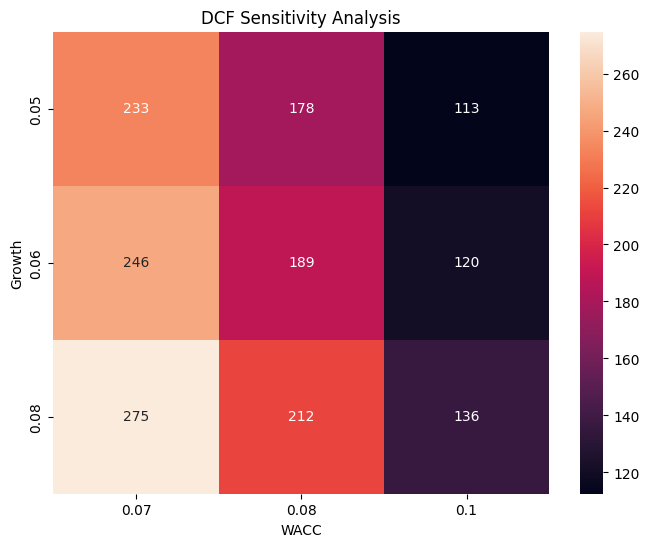

In [ ]:
# 📊 GRAPH 4
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(sensitivity.astype(float), annot=True, fmt=".0f")

plt.title("DCF Sensitivity Analysis")
plt.xlabel("WACC")
plt.ylabel("Growth")

plt.show()

### **DCF Sensitivity Heatmap**

The heatmap illustrates how the intrinsic value per share changes under different
assumptions for growth and WACC.

As expected:
- Higher growth rates increase valuation
- Higher discount rates (WACC) reduce valuation

The analysis shows a valuation range between approximately 112 USD and 275 USD per share.

Importantly, even under the most optimistic scenario (high growth and low WACC),
the estimated value remains significantly below the current market price.

This suggests that the market valuation cannot be justified by reasonable variations
in key assumptions, reinforcing the conclusion that the stock is overvalued.

The visualization also highlights the sensitivity of DCF models to small changes
in assumptions, particularly the discount rate.

### **Final Conclusion**

This analysis evaluated the intrinsic value of Casey’s General Stores using a Discounted Cash Flow (DCF) framework, complemented by peer comparison and sensitivity analysis.

The DCF model, based on normalized free cash flow, moderate growth assumptions, and a relatively low discount rate, estimates an intrinsic value significantly below the current market price. This valuation gap persists even under more optimistic scenarios, as demonstrated by the sensitivity analysis.

The peer comparison further supports this conclusion. Casey’s trades at a substantial premium relative to comparable companies, despite exhibiting similar or only moderately superior fundamentals in terms of growth and profitability.

Taken together, these results suggest that the current market valuation reflects expectations that go beyond what can be justified by the company’s fundamental cash-generating capacity under reasonable assumptions.

While Casey’s General Stores appears to be a high-quality and stable business with consistent performance, the stock price implies a level of optimism that introduces valuation risk.

From an investment perspective, this analysis would support a cautious stance. The company may remain attractive as a business, but the current price level does not offer a favorable risk–reward profile based on fundamental valuation.

**Conclusion:** The stock appears significantly overvalued and may warrant waiting for a more attractive entry point.
